In [ ]:
!pip install -q lightgbm shap

import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time as timer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df["Class"].value_counts())
print(f"Fraud rate: {df['Class'].mean():.4%}")
df.describe().T[["mean", "std", "min", "max"]]

Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%


,mean,std,min,max
Time,9.481386e+04,47488.145955,0.000000,172792.000000
V1,1.168375e-15,1.958696,-56.407510,2.454930
V2,3.416908e-16,1.651309,-72.715728,22.057729
V3,-1.379537e-15,1.516255,-48.325589,9.382558
V4,2.074095e-15,1.415869,-5.683171,16.875344
V5,9.604066e-16,1.380247,-113.743307,34.801666
V6,1.487313e-15,1.332271,-26.160506,73.301626
V7,-5.556467e-16,1.237094,-43.557242,120.589494
V8,1.213481e-16,1.194353,-73.216718,20.007208
V9,-2.406331e-15,1.098632,-13.434066,15.594995


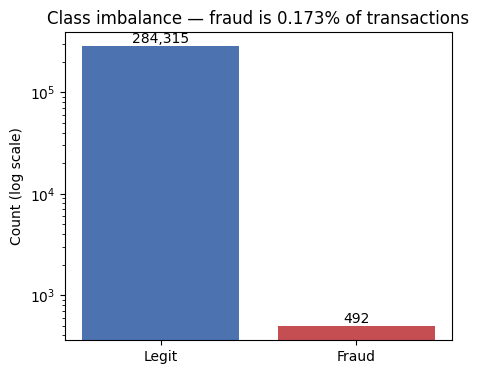

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Class"].value_counts()
ax.bar(["Legit", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Class imbalance — fraud is {df['Class'].mean():.3%} of transactions")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

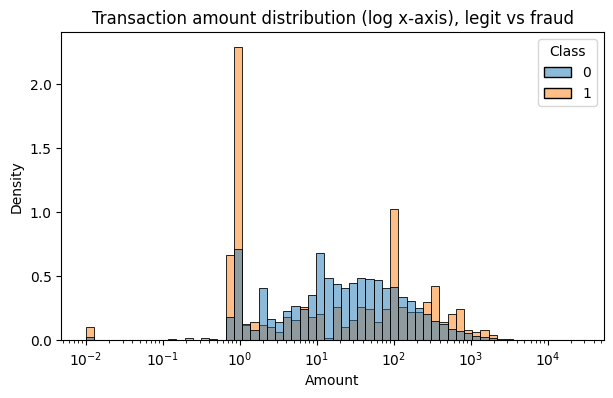

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="Amount", hue="Class", log_scale=(True, False),
             bins=60, stat="density", common_norm=False, ax=ax)
ax.set_title("Transaction amount distribution (log x-axis), legit vs fraud")
plt.show()

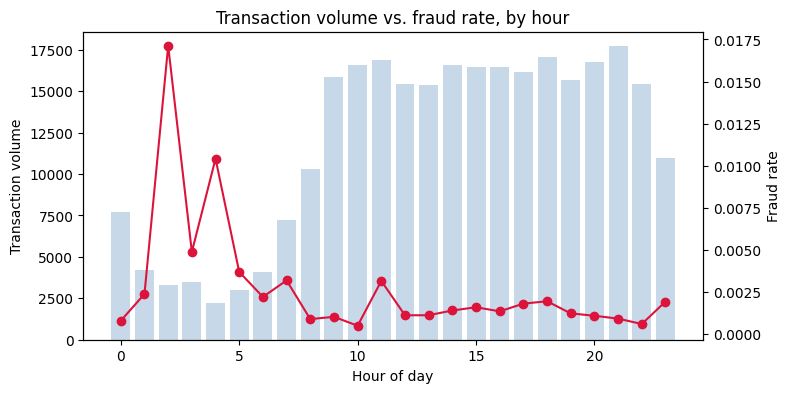

In [ ]:
df["Hour"] = (df["Time"] // 3600) % 24

fraud_rate_by_hour = df.groupby("Hour")["Class"].mean()
volume_by_hour = df.groupby("Hour").size()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(volume_by_hour.index, volume_by_hour.values, alpha=0.3, color="steelblue", label="Volume")
ax2.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color="crimson", marker="o", label="Fraud rate")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Transaction volume")
ax2.set_ylabel("Fraud rate")
ax1.set_title("Transaction volume vs. fraud rate, by hour")
plt.show()

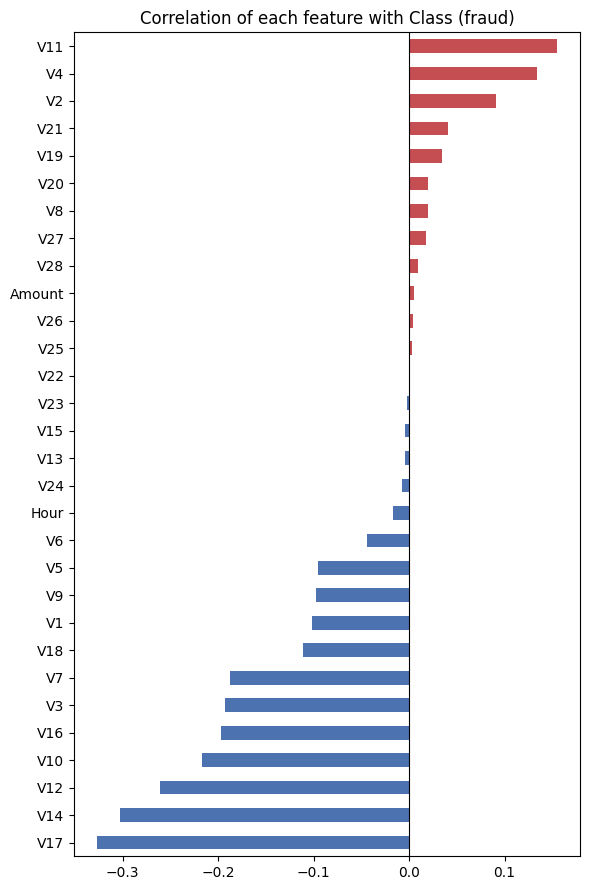

In [ ]:
corr_with_class = df.drop(columns=["Time"]).corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(6, 9))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in corr_with_class.values]
corr_with_class.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Correlation of each feature with Class (fraud)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

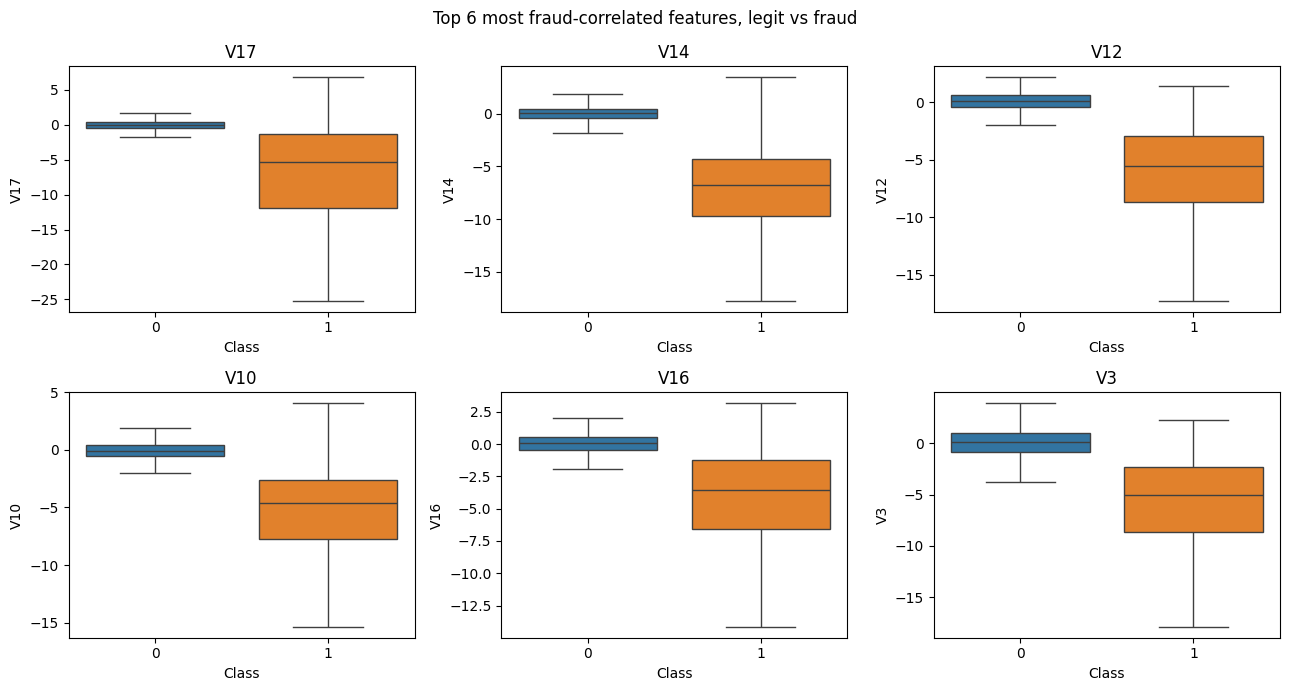

In [ ]:
top_feats = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flatten(), top_feats):
    sns.boxplot(data=df, x="Class", y=feat, ax=ax, hue="Class", legend=False, showfliers=False)
    ax.set_title(feat)
fig.suptitle("Top 6 most fraud-correlated features, legit vs fraud")
plt.tight_layout()
plt.show()

In [ ]:
df["Amount_log"] = np.log1p(df["Amount"])
df = df.sort_values("Time").reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in ["Class", "Time", "Amount"]]

split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]

X_train_full, y_train_full = train_df[feature_cols], train_df["Class"]
X_test, y_test = test_df[feature_cols], test_df["Class"]

# carve an early-stopping validation slice out of the tail of the training period
val_split_idx = int(len(train_df) * 0.85)
X_tr, y_tr = X_train_full.iloc[:val_split_idx], y_train_full.iloc[:val_split_idx]
X_val, y_val = X_train_full.iloc[val_split_idx:], y_train_full.iloc[val_split_idx:]

print("train / val / test sizes:", len(X_tr), len(X_val), len(X_test))
print("fraud rates:", y_tr.mean(), y_val.mean(), y_test.mean())

train / val / test sizes: 193668 34177 56962
fraud rates: 0.001967284218353058 0.0010533399654738566 0.001316667251852112


In [ ]:
import lightgbm as lgb
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

t0 = timer.time()
model = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # imbalance handling — no oversampling needed
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
)
print(f"Trained in {timer.time() - t0:.1f}s, stopped at iteration {model.best_iteration_}")

probs = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, probs))
print("PR-AUC:", average_precision_score(y_test, probs))
print(classification_report(y_test, (probs >= 0.5).astype(int), digits=3))

scale_pos_weight: 507.31496062992125
[LightGBM] [Info] Number of positive: 381, number of negative: 193287
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.152764 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7419
[LightGBM] [Info] Number of data points in the train set: 193668, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001967 -> initscore=-6.229132
[LightGBM] [Info] Start training from score -6.229132
Trained in 35.7s, stopped at iteration 395
ROC-AUC: 0.8392469281206603
PR-AUC: 0.6950818728043138
              precision    recall  f1-score   support

           0      1.000     0.999     1.000     56887
           1      0.617     0.667     0.641        75

    accuracy                          0.999     56962
   macro avg      0.808     0.833     0.820     56962
weighted avg      0.999     0.999     0.999     56962



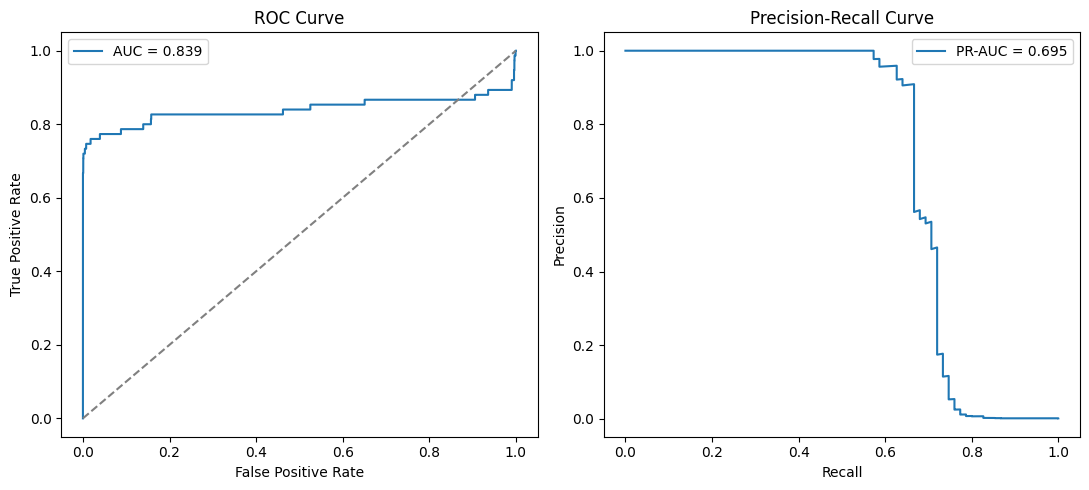

In [ ]:
fpr, tpr, _ = roc_curve(y_test, probs)
prec, rec, _ = precision_recall_curve(y_test, probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, probs):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

axes[1].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, probs):.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
plt.tight_layout()
plt.show()

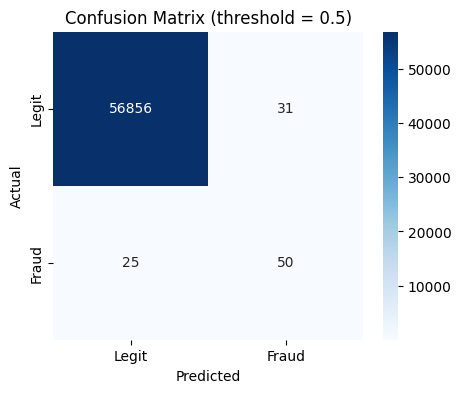

In [ ]:
preds = (probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

try:
    from sklearn.frozen import FrozenEstimator
    calibrated = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic")
except ImportError:
    calibrated = CalibratedClassifierCV(model, method="isotonic", cv="prefit")

calibrated.fit(X_val, y_val)
probs_cal = calibrated.predict_proba(X_test)[:, 1]
print("Calibrated PR-AUC:", average_precision_score(y_test, probs_cal))

Calibrated PR-AUC: 0.584028150832218


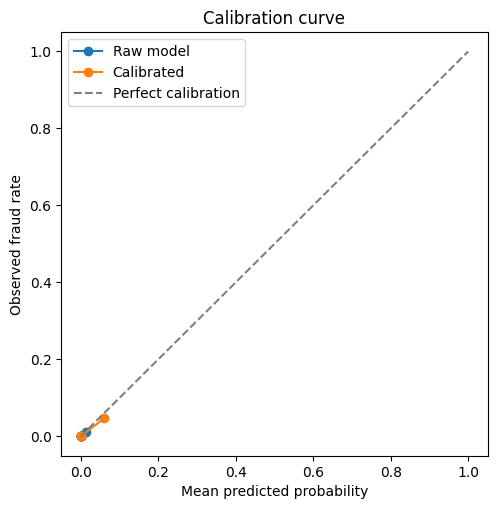

In [ ]:
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, probs_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Raw model")
ax.plot(mean_pred_cal, frac_pos_cal, marker="o", label="Calibrated")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraud rate")
ax.set_title("Calibration curve"); ax.legend()
plt.show()

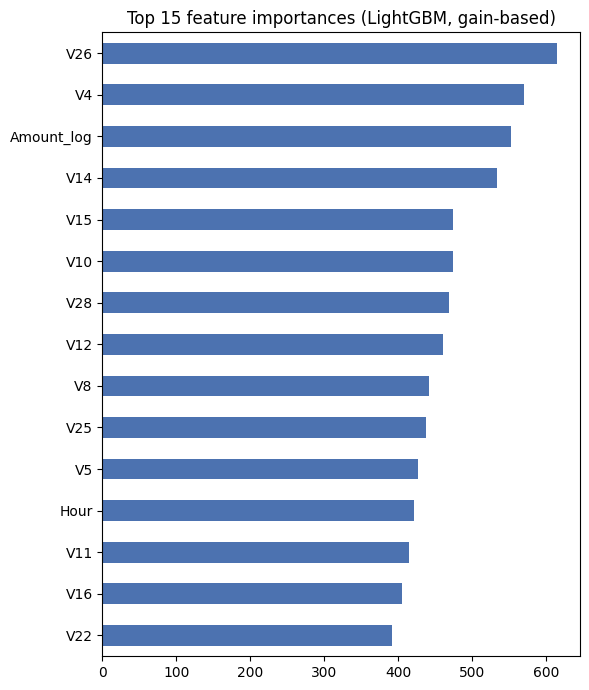

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 7))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 feature importances (LightGBM, gain-based)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_4346/2029927442.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, sample)


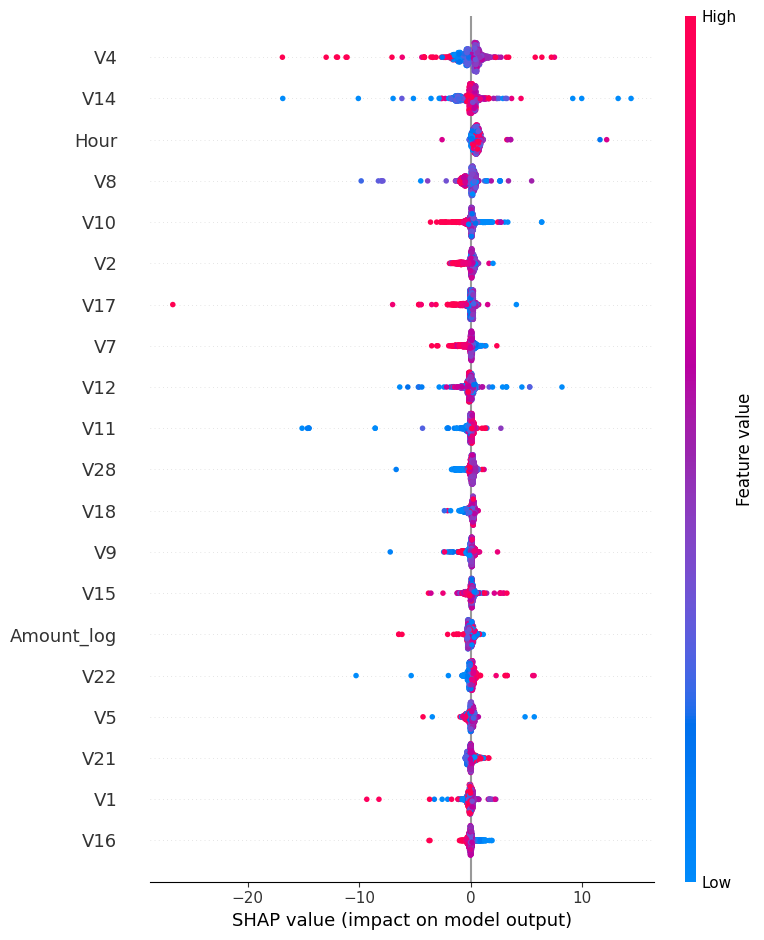

In [ ]:
import shap

sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, sample)

In [ ]:
COST_FALSE_NEGATIVE = 500   # avg $ lost per missed fraud — adjust to your data
COST_FALSE_POSITIVE = 5     # avg $ cost of investigating a false alarm — adjust to your data

thresholds = np.linspace(0.01, 0.99, 99)
costs, precisions, recalls, f1s = [], [], [], []

for t in thresholds:
    pred_t = (probs_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    costs.append(fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisions.append(p); recalls.append(r)
    f1s.append(2 * p * r / (p + r) if (p + r) > 0 else 0)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]
print(f"Cost-optimal threshold: {best_threshold:.3f}  (estimated cost: ${costs[best_idx]:,.0f})")
print(f"At this threshold — precision: {precisions[best_idx]:.3f}, recall: {recalls[best_idx]:.3f}")

Cost-optimal threshold: 0.030  (estimated cost: $10,835)
At this threshold — precision: 0.446, recall: 0.720


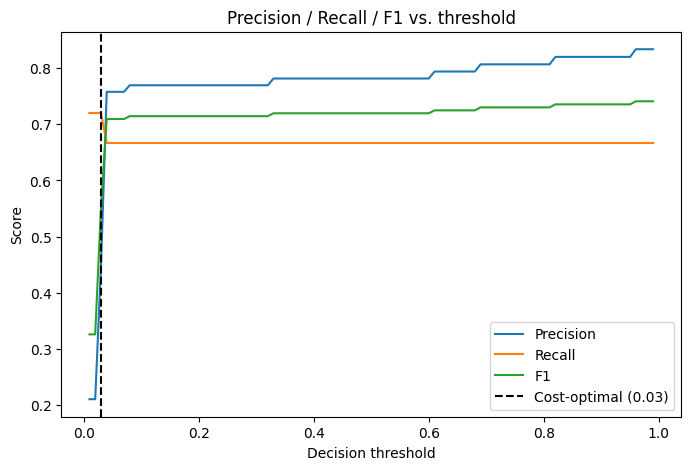

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label="Precision")
ax.plot(thresholds, recalls, label="Recall")
ax.plot(thresholds, f1s, label="F1")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Cost-optimal ({best_threshold:.2f})")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. threshold")
ax.legend()
plt.show()

In [ ]:
final_preds = (probs_cal >= best_threshold).astype(int)
print(f"Final performance at threshold = {best_threshold:.3f}")
print(confusion_matrix(y_test, final_preds))
print(classification_report(y_test, final_preds, digits=3))

import joblib
joblib.dump(model, "fraud_model_lgbm.pkl")
joblib.dump(calibrated, "fraud_model_calibrated.pkl")
print("Models saved.")

Final performance at threshold = 0.030
[[56820    67]
 [   21    54]]
              precision    recall  f1-score   support

           0      1.000     0.999     0.999     56887
           1      0.446     0.720     0.551        75

    accuracy                          0.998     56962
   macro avg      0.723     0.859     0.775     56962
weighted avg      0.999     0.998     0.999     56962

Models saved.


In [ ]:
window = 50
df["roll_amount_mean"] = df["Amount"].rolling(window, min_periods=5).mean().shift(1)
df["roll_amount_std"] = df["Amount"].rolling(window, min_periods=5).std().shift(1)
df["amount_zscore"] = (df["Amount"] - df["roll_amount_mean"]) / (df["roll_amount_std"] + 1e-6)
df["time_since_last"] = df["Time"].diff().fillna(df["Time"].median())

# transactions in the trailing 1hr window (two-pointer, fast even at 280k+ rows)
time_vals = df["Time"].values
counts = np.zeros(len(df))
left = 0
window_secs = 3600
for i in range(len(df)):
    while time_vals[left] < time_vals[i] - window_secs:
        left += 1
    counts[i] = i - left
df["txn_count_last_hour"] = counts

df[["roll_amount_mean", "roll_amount_std", "amount_zscore"]] = \
    df[["roll_amount_mean", "roll_amount_std", "amount_zscore"]].fillna(0)

print(df[["amount_zscore", "time_since_last", "txn_count_last_hour"]].describe())

       amount_zscore  time_since_last  txn_count_last_hour
count  284807.000000    284807.000000        284807.000000
mean        0.099892         0.904065          7245.357618
std         1.949869       158.698753          2113.996409
min        -3.493006         0.000000             0.000000
25%        -0.459918         0.000000          7407.000000
50%        -0.317381         0.000000          7941.000000
75%        -0.023096         1.000000          8391.000000
max       207.158837     84692.000000         10553.000000


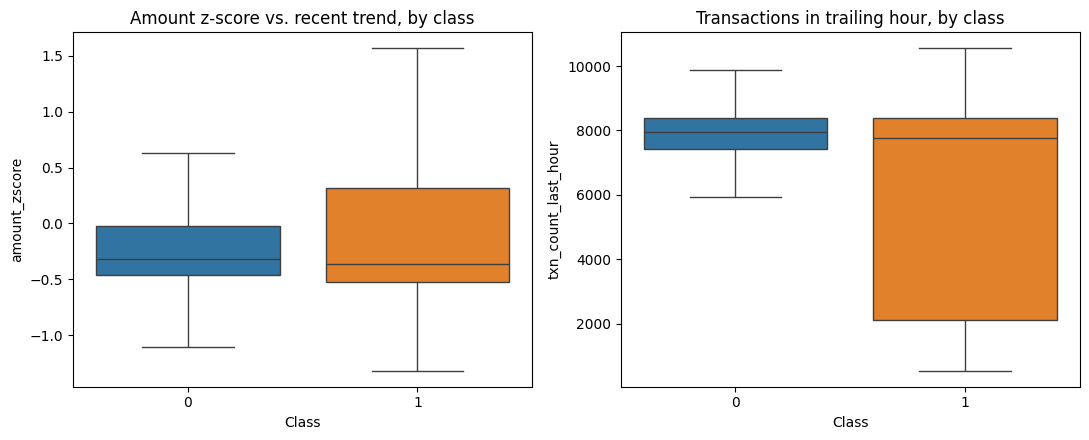

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x="Class", y="amount_zscore", hue="Class", legend=False, ax=axes[0], showfliers=False)
axes[0].set_title("Amount z-score vs. recent trend, by class")
sns.boxplot(data=df, x="Class", y="txn_count_last_hour", hue="Class", legend=False, ax=axes[1], showfliers=False)
axes[1].set_title("Transactions in trailing hour, by class")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

feature_cols = [c for c in df.columns if c not in ["Class", "Time", "Amount"]]
X, y = df[feature_cols], df["Class"]

tscv = TimeSeriesSplit(n_splits=5)
fold_scores = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
    X_tr_f, X_te_f = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr_f, y_te_f = y.iloc[tr_idx], y.iloc[te_idx]
    spw = (y_tr_f == 0).sum() / (y_tr_f == 1).sum()
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                            scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    m.fit(X_tr_f, y_tr_f)
    score = average_precision_score(y_te_f, m.predict_proba(X_te_f)[:, 1])
    fold_scores.append(score)
    print(f"Fold {fold}: train={len(X_tr_f):,}  test={len(X_te_f):,}  PR-AUC={score:.4f}")

print(f"\nMean PR-AUC: {np.mean(fold_scores):.4f}  ±{np.std(fold_scores):.4f}")

Fold 0: train=47,472  test=47,467  PR-AUC=0.0670
Fold 1: train=94,939  test=47,467  PR-AUC=0.0370
Fold 2: train=142,406  test=47,467  PR-AUC=0.0658
Fold 3: train=189,873  test=47,467  PR-AUC=0.0859
Fold 4: train=237,340  test=47,467  PR-AUC=0.0036

Mean PR-AUC: 0.0519  ±0.0287


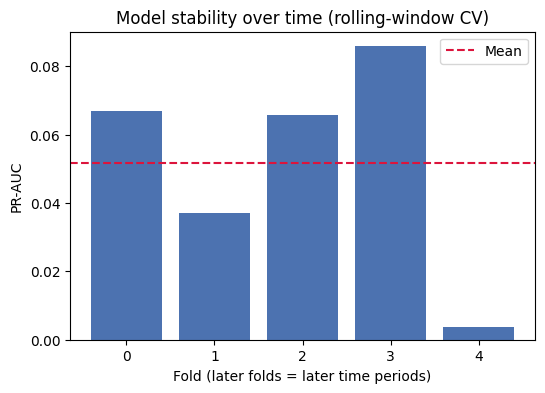

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(fold_scores)), fold_scores, color="#4C72B0")
ax.axhline(np.mean(fold_scores), color="crimson", linestyle="--", label="Mean")
ax.set_xlabel("Fold (later folds = later time periods)")
ax.set_ylabel("PR-AUC")
ax.set_title("Model stability over time (rolling-window CV)")
ax.legend()
plt.show()

In [ ]:
split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]
val_split_idx = int(len(train_df) * 0.85)

X_tr = train_df[feature_cols].iloc[:val_split_idx]
y_tr = train_df["Class"].iloc[:val_split_idx]
X_val = train_df[feature_cols].iloc[val_split_idx:]
y_val = train_df["Class"].iloc[val_split_idx:]
X_test, y_test = test_df[feature_cols], test_df["Class"]

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

In [ ]:
!pip install -q optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight,
        "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(30, verbose=False)])
    return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30)  # ~10-15 min on Colab CPU; drop to 15 trials if you're in a hurry

print("Best validation PR-AUC:", study.best_value)
print("Best params:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.7 MB/s eta 0:00:00
Best validation PR-AUC: 0.8114600340994212
Best params: {'learning_rate': 0.028113002186520703, 'num_leaves': 72, 'min_child_samples': 81, 'subsample': 0.9508096412230285, 'colsample_bytree': 0.9951831798581992, 'reg_alpha': 0.2884029792927384, 'reg_lambda': 1.575075411247877}


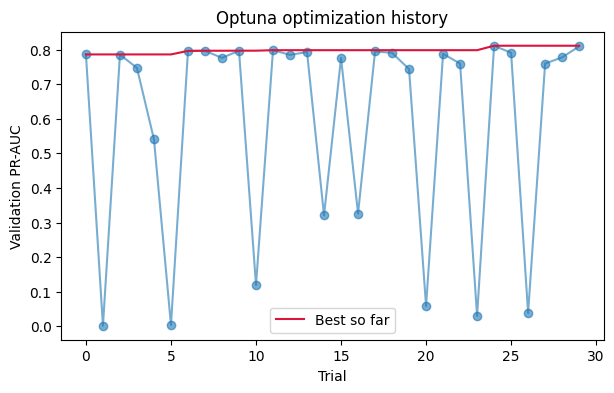

In [ ]:
trial_values = [t.value for t in study.trials]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trial_values, marker="o", alpha=0.6)
ax.plot(np.maximum.accumulate(trial_values), color="crimson", label="Best so far")
ax.set_xlabel("Trial"); ax.set_ylabel("Validation PR-AUC")
ax.set_title("Optuna optimization history")
ax.legend()
plt.show()

In [ ]:
monotone_constraints = [1 if c == "Amount_log" else 0 for c in feature_cols]
sample_weight = 1.0 + (train_df["Amount"].iloc[:val_split_idx].values / train_df["Amount"].iloc[:val_split_idx].max())

final_params = dict(study.best_params)
final_params.update({
    "n_estimators": 3000, "scale_pos_weight": scale_pos_weight,
    "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1,
    "monotone_constraints": monotone_constraints,
})

lgbm_final = lgb.LGBMClassifier(**final_params)
lgbm_final.fit(X_tr, y_tr, sample_weight=sample_weight,
               eval_set=[(X_val, y_val)], eval_metric="average_precision",
               callbacks=[lgb.early_stopping(100, verbose=False)])

probs_lgbm = lgbm_final.predict_proba(X_test)[:, 1]
print("Tuned LightGBM PR-AUC:", average_precision_score(y_test, probs_lgbm))

Tuned LightGBM PR-AUC: 0.7661663981663679


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.002, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_tr[y_tr == 0])

iso_scores_test = -iso.score_samples(X_test)   # higher = more anomalous
iso_scores_val = -iso.score_samples(X_val)
iso_norm_test = (iso_scores_test - iso_scores_test.min()) / (iso_scores_test.max() - iso_scores_test.min())

print("IsolationForest alone, PR-AUC:", average_precision_score(y_test, iso_scores_test))

IsolationForest alone, PR-AUC: 0.037877093826639


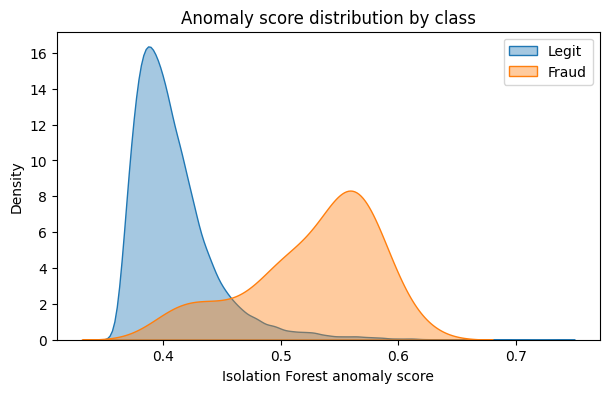

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(iso_scores_test[y_test == 0], label="Legit", ax=ax, fill=True, alpha=0.4)
sns.kdeplot(iso_scores_test[y_test == 1], label="Fraud", ax=ax, fill=True, alpha=0.4)
ax.set_xlabel("Isolation Forest anomaly score"); ax.set_title("Anomaly score distribution by class")
ax.legend()
plt.show()

In [ ]:
!pip install -q xgboost catboost
import xgboost as xgb
import catboost as cb

xgbm = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.03, max_depth=6,
                          subsample=0.8, colsample_bytree=0.8,
                          scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1,
                          eval_metric="aucpr", early_stopping_rounds=50)
xgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

cbm = cb.CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6,
                             scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                             eval_metric="PRAUC", early_stopping_rounds=50, verbose=False)
cbm.fit(X_tr, y_tr, eval_set=(X_val, y_val))

probs_xgbm = xgbm.predict_proba(X_test)[:, 1]
probs_cbm = cbm.predict_proba(X_test)[:, 1]
print("XGBoost PR-AUC:", average_precision_score(y_test, probs_xgbm))
print("CatBoost PR-AUC:", average_precision_score(y_test, probs_cbm))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00
XGBoost PR-AUC: 0.7681956085661948
CatBoost PR-AUC: 0.7705967473570385


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

def calibrate(model, X_val, y_val):
    try:
        from sklearn.frozen import FrozenEstimator
        c = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic")
    except ImportError:
        c = CalibratedClassifierCV(model, method="isotonic", cv="prefit")
    c.fit(X_val, y_val)
    return c

lgbm_cal = calibrate(lgbm_final, X_val, y_val)
xgbm_cal = calibrate(xgbm, X_val, y_val)
cbm_cal = calibrate(cbm, X_val, y_val)

p_lgbm = lgbm_cal.predict_proba(X_test)[:, 1]
p_xgbm = xgbm_cal.predict_proba(X_test)[:, 1]
p_cbm = cbm_cal.predict_proba(X_test)[:, 1]

ensemble = 0.34 * p_lgbm + 0.33 * p_xgbm + 0.33 * p_cbm
ensemble_final = 0.9 * ensemble + 0.1 * iso_norm_test   # small anomaly-score blend-in

print("Ensemble (3 models) PR-AUC:", average_precision_score(y_test, ensemble))
print("Ensemble + IsoForest PR-AUC:", average_precision_score(y_test, ensemble_final))

Ensemble (3 models) PR-AUC: 0.7647728684125948
Ensemble + IsoForest PR-AUC: 0.7611858879199206


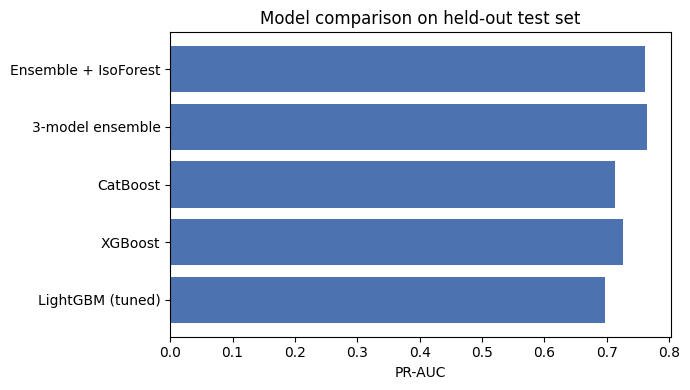

In [ ]:
scores = {
    "LightGBM (tuned)": average_precision_score(y_test, p_lgbm),
    "XGBoost": average_precision_score(y_test, p_xgbm),
    "CatBoost": average_precision_score(y_test, p_cbm),
    "3-model ensemble": average_precision_score(y_test, ensemble),
    "Ensemble + IsoForest": average_precision_score(y_test, ensemble_final),
}
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(scores.keys()), list(scores.values()), color="#4C72B0")
ax.set_xlabel("PR-AUC"); ax.set_title("Model comparison on held-out test set")
plt.tight_layout()
plt.show()

In [ ]:
COST_FALSE_NEGATIVE = 500
COST_FALSE_POSITIVE = 5

thresholds = np.linspace(0.01, 0.99, 99)
costs, precisions, recalls, f1s = [], [], [], []
for t in thresholds:
    pred_t = (ensemble_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    costs.append(fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisions.append(p); recalls.append(r)
    f1s.append(2 * p * r / (p + r) if (p + r) > 0 else 0)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]
print(f"Cost-optimal threshold: {best_threshold:.3f} (est. cost ${costs[best_idx]:,.0f})")
print(f"Precision: {precisions[best_idx]:.3f}  Recall: {recalls[best_idx]:.3f}")

Cost-optimal threshold: 0.090 (est. cost $9,130)
Precision: 0.687  Recall: 0.760


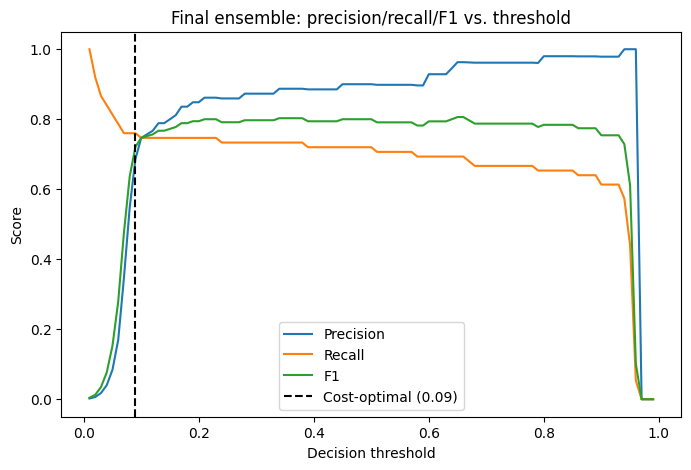

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label="Precision")
ax.plot(thresholds, recalls, label="Recall")
ax.plot(thresholds, f1s, label="F1")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Cost-optimal ({best_threshold:.2f})")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Final ensemble: precision/recall/F1 vs. threshold")
ax.legend()
plt.show()

In [ ]:
import shap
explainer = shap.TreeExplainer(lgbm_final)

def reason_codes(row_index_in_test, top_n=3):
    row = X_test.iloc[[row_index_in_test]]
    sv = explainer.shap_values(row)
    sv = sv[1] if isinstance(sv, list) else sv
    contribs = pd.Series(sv[0], index=feature_cols).sort_values(key=np.abs, ascending=False)
    return contribs.head(top_n)

In [ ]:
flagged_idx = np.where(ensemble_final >= best_threshold)[0][:3]
for i in flagged_idx:
    print(f"\nTransaction #{i} — model score: {ensemble_final[i]:.3f}, actual class: {y_test.iloc[i]}")
    print("Top contributing factors:")
    print(reason_codes(i))


Transaction #76 — model score: 0.099, actual class: 0
Top contributing factors:
V25    2.928777
V4     2.553678
V10    2.330792
dtype: float64

Transaction #313 — model score: 0.092, actual class: 0
Top contributing factors:
V4    3.986862
V7   -2.004692
V3    1.631473
dtype: float64

Transaction #659 — model score: 0.596, actual class: 0
Top contributing factors:


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


V14    9.858763
V10    4.655988
V4     3.050308
dtype: float64


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
import joblib
joblib.dump(lgbm_final, "fraud_lgbm_final.pkl")
joblib.dump(xgbm, "fraud_xgb.pkl")
joblib.dump(cbm, "fraud_catboost.pkl")
joblib.dump(iso, "fraud_isoforest.pkl")
joblib.dump({"lgbm_cal": lgbm_cal, "xgbm_cal": xgbm_cal, "cbm_cal": cbm_cal}, "fraud_calibrators.pkl")
print("All models saved.")

All models saved.
